<a href="https://colab.research.google.com/github/Ololade117/Research-Papers/blob/main/A_Neural_Probabilistic_Language_Model_by_Yoshua_Bengio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Work in Progress. Error a bit too **Large.** DO NOT  RUN ALL

##Implementation of  A Neural Probabilistic Language Model by Yoshua Bengio,Réjean Ducharme Pascal Vincent Christian Jauvin##[ A Neural Probabilistic Language Model](https://https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

In [1]:
import torch
from collections import Counter
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
device = "cuda"

In [3]:
import nltk
nltk.download('brown')
from nltk.corpus import brown

# Example: Get the words from the Brown corpus
brown_sents = brown.sents()
print(f"Number of sentences in Brown corpus: {len(brown_sents)}")
print(f"First 10 Sentences : {brown_sents[:10]}")
print(len(brown_sents))

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


Number of sentences in Brown corpus: 57340
First 10 Sentences : [['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.'], ['The', 'jury', 'further', 'said', 'in', 'term-end', 'presentments', 'that', 'the', 'City', 'Executive', 'Committee', ',', 'which', 'had', 'over-all', 'charge', 'of', 'the', 'election', ',', '``', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'City', 'of', 'Atlanta', "''", 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted', '.'], ['The', 'September-October', 'term', 'jury', 'had', 'been', 'charged', 'by', 'Fulton', 'Superior', 'Court', 'Judge', 'Durwood', 'Pye', 'to', 'investigate', 'reports', 'of', 'possible', '``', 'irregularities', "''", 'in', 'the', 'hard-fought', 'primary', 'which', 'was', 'won', 'by', 'Mayor-nominate', 'Ivan', 'Allen', 'Jr.', '.'

In [4]:
#Build Vocabulary
processed = []

N = 5 # Context window

for sents in brown_sents:
  sents = [sent.lower() for sent in sents]
  sents = (
      ["<BOS>"] * N
      + sents
      + ["<EOS>"]

  )
  processed.extend(sents)

print(len(processed))

1505232


In [5]:
#Build Vocabulary 2
word_counts = Counter(processed)
#print(word_counts.most_common()[-100:])

MIN_FREQ = 1   # 10% of the sentence
vocab = {
    word
    for word, count in word_counts.items()
    if count > MIN_FREQ
}

len(vocab)

27807

In [6]:
special_tokens = [
    "<PAD>",
    "<UNK>",
    "<BOS>",
    "<EOS>"
]
vocab = sorted(set(vocab).union(special_tokens))
print(len(vocab))   # len(vocab) should increase by 2




27809


In [7]:
# Convert words to indices

word2idx = {
    words : idx
    for idx, words in enumerate(vocab)
}

idx2words ={
    idx : words
    for words, idx in word2idx.items()
}

In [8]:
vocab = set(vocab)
unk = word2idx["<UNK>"]

encoded_sentence = [
    word2idx.get(word, unk)
    if word in vocab
    else unk
    for word in processed
]

In [9]:
#Generate context ----> target
X, Y = [], []


for i in range(N, len(encoded_sentence)):

  target  = encoded_sentence[i]

  if target == word2idx["<BOS>"]:
    continue

  X.append(encoded_sentence[i-N:i])
  Y.append(target)



X = torch.tensor(X)
Y = torch.tensor(Y)
encoded_vocab = torch.tensor(list(word2idx.values()))

X = X.to(device)
Y = Y.to(device)

print(X.shape, Y.shape)

torch.Size([1218532, 5]) torch.Size([1218532])


In [12]:
#to check if we are predicting BOS
bos = word2idx["<BOS>"]

print((Y == bos).sum())

tensor(0, device='cuda:0')


In [12]:
# Make embeddings of vocab
C = torch.randn(encoded_vocab.size(0), 32).to(device)
emb = C[X]
print(f"The shape of the embedding : {emb.shape}")

# Make parameters
w1 = torch.randn(160, 50) * 0.01
b1 = torch.randn(50)

w2 = torch.randn(50, encoded_vocab.shape[0]) *0.01
b2 = torch.randn(encoded_vocab.shape[0]) *0

bngain = torch.ones((1, 50))
bnbias = torch.zeros((1, 50))

params = [C, w1, b1, w2, b2, bngain, bnbias] # b1 added to params
print(f"The number of parameters :{sum(n.nelement() for n in params)}")

for p in params:
  p.data = p.data.to(device)

The shape of the embedding : torch.Size([1218532, 5, 32])
The number of parameters :2316297


In [ ]:
# @title
# learning rate tuning
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = []
lossi = []

for p in parameters:
  p.requires_grad = True


for i in range(1000):

  #mini batch
  ix = torch.randint(0, xtr.shape[0], (64,))

  #forward pass
  emb = C[xtr[ix]]
  h = torch.tanh(emb.view(-1,12) @ w1 + b1)
  logits = h @ w2 + b2
  loss = F.cross_entropy(logits, ytr[ix])
  #print(loss.item())


  #backward pass
  for a in parameters:
    a.grad = None

  loss.backward()

  #update params
  lr = lrs[i]

  for b in parameters:
    b.data += - lr*b.grad

  #keepin track
  lri.append(lre[i])
  lossi.append(loss.item())

#print(loss.item())

plt.plot(lri, lossi)

Loss: 7.178699493408203


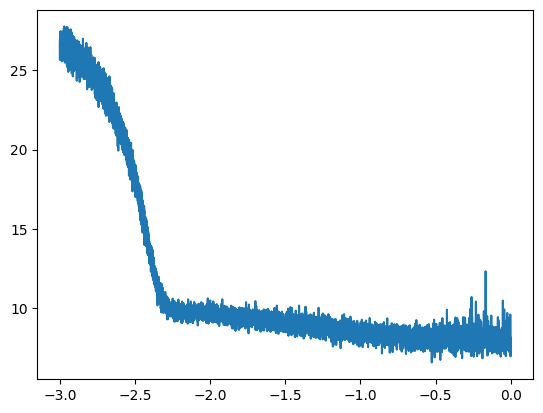

In [20]:
# @title
# learning rate tuning
lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre

lri = []
lossi = []
for p in params:
  p.requires_grad = True

for i in range(10000): # Increased training iterations to 200,000
  # Batch size
  ix = torch.randint(0, X.shape[0], (128,))

  #forward pass
  #-------------BATCH NORM------------
  emb = C[X[ix]]
  embcat = emb.view((emb.shape[0], -1))            # flatten (concatenate the vectors)
  hpreact = embcat @ w1 + b1
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True) + 1e-5 # Added epsilon for numerical stability
  hpreact = bngain*((hpreact - bnmeani )/bnstdi) + bnbias
  #----------------------------------------------------------------------------------------------------------

  h = torch.tanh(hpreact)
  logits = h@w2 +b2
  loss = F.cross_entropy(logits, Y[ix])
  #print(f"Loss: {loss}")


  #backward pass
  for p in params:
    p.grad = None

  loss.backward()

  #update params
  lr = lrs[i]
  #lr = 0.1 if i < 100000 else 0.01

  for p in params:
    p.data += -lr*p.grad

  lri.append(lre[i])
  lossi.append(loss.item())

print(f"Loss: {loss}")

plt.plot(lri, lossi)

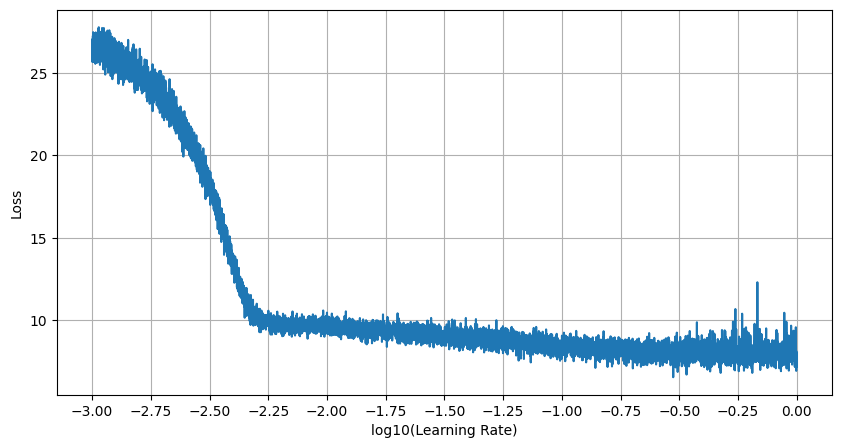

In [21]:
# @title
import numpy as np

plt.figure(figsize=(10, 5))
plt.plot(lri, lossi)

plt.xticks(np.arange(-3, 0.1, 0.25))  # Tick every 0.25
plt.xlabel("log10(Learning Rate)")
plt.ylabel("Loss")
plt.grid(True)

plt.show()


In [20]:
# @title
for p in params:
  p.requires_grad = True

for i in range(50000):
  # Batch size
  ix = torch.randint(0, X.shape[0], (1024,))

  #forward pass
  #-------------BATCH NORM------------
  emb = C[X[ix]]
  embcat = emb.view((emb.shape[0], -1))            # flatten (concatenate the vectors)
  hpreact = embcat @ w1 + b1
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True) + 1e-5 # Added epsilon for numerical stability
  hpreact = bngain*((hpreact - bnmeani )/bnstdi) + bnbias
  #-------------HAD TO REMOVE BATCH NORM AND INCREASE BATCH SIZE-------------

  h = torch.tanh(hpreact)
  logits = h@w2 +b2
  loss = F.cross_entropy(logits, Y[ix])

  if i%1000 == 0:
    print(f"Loss: {loss}")


  #backward pass
  for p in params:
    p.grad = None

  loss.backward()

  #update params
  #lr = 0.1 if i < 100000 else 0.01

  for p in params:
    p.data += -0.00001*p.grad

print(f"Loss: {loss}")

Loss: 6.696689605712891
Loss: 6.5835700035095215
Loss: 6.625807762145996
Loss: 6.566843032836914
Loss: 6.752551078796387
Loss: 6.727518558502197
Loss: 6.686516284942627
Loss: 6.590451717376709
Loss: 6.5491533279418945
Loss: 6.666306495666504
Loss: 6.67261266708374
Loss: 6.541834831237793
Loss: 6.659646034240723
Loss: 6.582370281219482
Loss: 6.4628167152404785
Loss: 6.645807266235352
Loss: 6.491473197937012
Loss: 6.780096530914307
Loss: 6.640461444854736
Loss: 6.745328903198242
Loss: 6.65600061416626
Loss: 6.489423751831055
Loss: 6.701162338256836
Loss: 6.664183139801025
Loss: 6.8342719078063965
Loss: 6.52473258972168
Loss: 6.712281227111816
Loss: 6.8920135498046875
Loss: 6.62515115737915
Loss: 6.708492279052734
Loss: 6.598944664001465
Loss: 6.51589298248291
Loss: 6.816411018371582
Loss: 6.655936241149902
Loss: 6.452606678009033
Loss: 6.424561977386475
Loss: 6.572643280029297
Loss: 6.504448890686035
Loss: 6.791227340698242
Loss: 6.636471748352051
Loss: 6.635253429412842
Loss: 6.48401832

In [26]:
sampled_words = []
current_context = [word2idx['<BOS>']] * N

for _ in range(50):

    context_tensor = torch.tensor([current_context]).to(device)

    emb = C[context_tensor]  # Corrected from C(context_tensor)

    h = torch.tanh(emb.view(emb.shape[0], -1) @ w1 + b1)
    logits = h @ w2 + b2

    probabilities = F.softmax(logits, dim=1)
    next_word_idx = torch.multinomial(probabilities, num_samples=1).item()

    next_word = idx2words[next_word_idx]
    sampled_words.append(next_word)

    if next_word == '<EOS>':
        break

    current_context = current_context[1:] + [next_word_idx]

print(" ".join(sampled_words))

jobless ! are electrons districts waged expanse quemoy overhangs postman nuns walton closed sighed dallas prodded reluctant dora advantage plodding justifiable cowboys handicap glee provinces tao sims 1/8'' salient republicans overestimation brooklyn 1899 snead gym limbo light-colored ban fox maude authorization hurrays vernava consoled ordinance sacred meats disappointment rooftop dick


In [50]:
from collections import Counter

target_counts = Counter(Y.tolist())

print(target_counts.most_common(10))

[(809, 172017), (24984, 69971), (121, 58334), (810, 57340), (126, 49346), (17300, 36412), (1719, 28853), (25325, 26158), (817, 23195), (812, 22010)]


In [51]:
idx2words[809]

'<BOS>'